In [1]:
import sys
import json
sys.path.append('..')
from Main.Experiment_class import *
from Utils.theoretical_points import *
from copy import deepcopy

In [2]:
markersize = 15
capsize = 6
capthick = 2
linewidth = 7.5
elinewidth=2

In [3]:
obj = PIcode_experiment(None, False, False)
obj.load('../Data/31st_August_Torino_run1.json')
N = obj.storage['multi_qec_30_1']['shots']
rec_time = obj.recovery_time*obj.dt/1e3
enc_time = obj.encoder_time*obj.dt/1e3
delays = obj.storage['bare_qubit']['delays']

In [16]:
times = np.linspace(0, 300, 601)
delays_multi = np.array(obj.storage['bare_qubit']['delays'])
relaxation_time = 30
for i in range(len(delays_multi)):
    t = int(np.ceil(delays_multi[i]/30))
    if t  == 0:
        t = 1
    delays_multi[i] += t*rec_time
delays_multi += 2*enc_time

In [17]:
objsim = PIcode_experiment(None, False, False)
objsim.load('../Data/T290_simulation.json')

In [18]:
N = 52000
N_bare = 2000

In [19]:
fids_set_1_ket0 = np.array(obj.storage[f'multi_qec_30_0']['fids']['4'])
fids_set_1_ket1 = np.array(obj.storage[f'multi_qec_30_1']['fids']['4'])
fids_set_2_ket0 = np.array(obj.storage[f'multi_qec_30_0']['fids']['5'])
fids_set_2_ket1 = np.array(obj.storage[f'multi_qec_30_1']['fids']['5'])
fids_set_3_ket0 = np.array(obj.storage[f'multi_qec_30_0']['fids']['6'])
fids_set_3_ket1 = np.array(obj.storage[f'multi_qec_30_1']['fids']['6'])
fid_stds_set_1_ket0 = np.array(obj.storage[f'multi_qec_30_0']['fids_stds']['4'])
fid_stds_set_1_ket1 = np.array(obj.storage[f'multi_qec_30_1']['fids_stds']['4'])
fid_stds_set_2_ket0 = np.array(obj.storage[f'multi_qec_30_0']['fids_stds']['5'])
fid_stds_set_2_ket1 = np.array(obj.storage[f'multi_qec_30_1']['fids_stds']['5'])
fid_stds_set_3_ket0 = np.array(obj.storage[f'multi_qec_30_0']['fids_stds']['6'])
fid_stds_set_3_ket1 = np.array(obj.storage[f'multi_qec_30_1']['fids_stds']['6'])

In [20]:
p_set_1_ket0 = np.array(obj.storage['multi_qec_30_0']['success_rates']['4'])
p_set_1_ket1 = np.array(obj.storage['multi_qec_30_1']['success_rates']['4'])
p_set_2_ket0 = np.array(obj.storage['multi_qec_30_0']['success_rates']['5'])
p_set_2_ket1 = np.array(obj.storage['multi_qec_30_1']['success_rates']['5'])
p_set_3_ket0 = np.array(obj.storage['multi_qec_30_0']['success_rates']['6'])
p_set_3_ket1 = np.array(obj.storage['multi_qec_30_1']['success_rates']['6'])

In [21]:
n = 12
bare_qubit_fids = np.array(obj.storage['bare_qubit']['fids']['58'])
bare_stds = np.array(obj.storage['bare_qubit']['fids_stds']['58'])
bare_snr_set_1 = [ snr_exp(f, s, N_bare/n) for f, s in zip(bare_qubit_fids, bare_stds) ]
bare_qubit_fids = np.array(obj.storage['bare_qubit']['fids']['33'])
bare_stds = np.array(obj.storage['bare_qubit']['fids_stds']['33'])
bare_snr_set_2 = [ snr_exp(f, s, N_bare/n) for f, s in zip(bare_qubit_fids, bare_stds) ]
bare_qubit_fids = np.array(obj.storage['bare_qubit']['fids']['101'])
bare_stds = np.array(obj.storage['bare_qubit']['fids_stds']['101'])
bare_snr_set_3 = [ snr_exp(f, s, N_bare/n) for f, s in zip(bare_qubit_fids, bare_stds) ]

In [22]:
snr_set_1_ket0 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_set_1_ket0, fid_stds_set_1_ket0)
])
snr_set_1_ket1 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_set_1_ket1, fid_stds_set_1_ket1)
])
snr_set_2_ket0 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_set_2_ket0, fid_stds_set_2_ket0)
])
snr_set_2_ket1 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_set_2_ket1, fid_stds_set_2_ket1)
])
snr_set_3_ket0 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_set_3_ket0, fid_stds_set_3_ket0)
])
snr_set_3_ket1 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_set_3_ket1, fid_stds_set_3_ket1)
])

# Set 1

In [44]:
set1_T1 = 205
set1_T2 = 90
qubit_set1 = obj.storage['multi_qec_30_1']['qubit_pos'][4]
bare_f_measure = [obj.storage['bare_qubit']['fids'][f'{qubit}'][0] for qubit in qubit_set1]

In [49]:
data_set1 = get_th_approx_data(set1_T1, set1_T2, times, 30)
bare_snr_set_1_th = snr_th(f=data_set1['bare_qubit']['fids'], p=1.0, f_measure=bare_f_measure[1], n_measure=1)
snr_set_1_ket0_th = snr_th(f=data_set1['multi_qec_0_approx']['fids'], p=data_set1['multi_qec_0_approx']['probs'], f_measure=np.mean(bare_f_measure), n_measure=4)
snr_set_1_ket1_th = snr_th(f=data_set1['multi_qec_1_approx']['fids'], p=data_set1['multi_qec_1_approx']['probs'], f_measure=np.mean(bare_f_measure), n_measure=4)

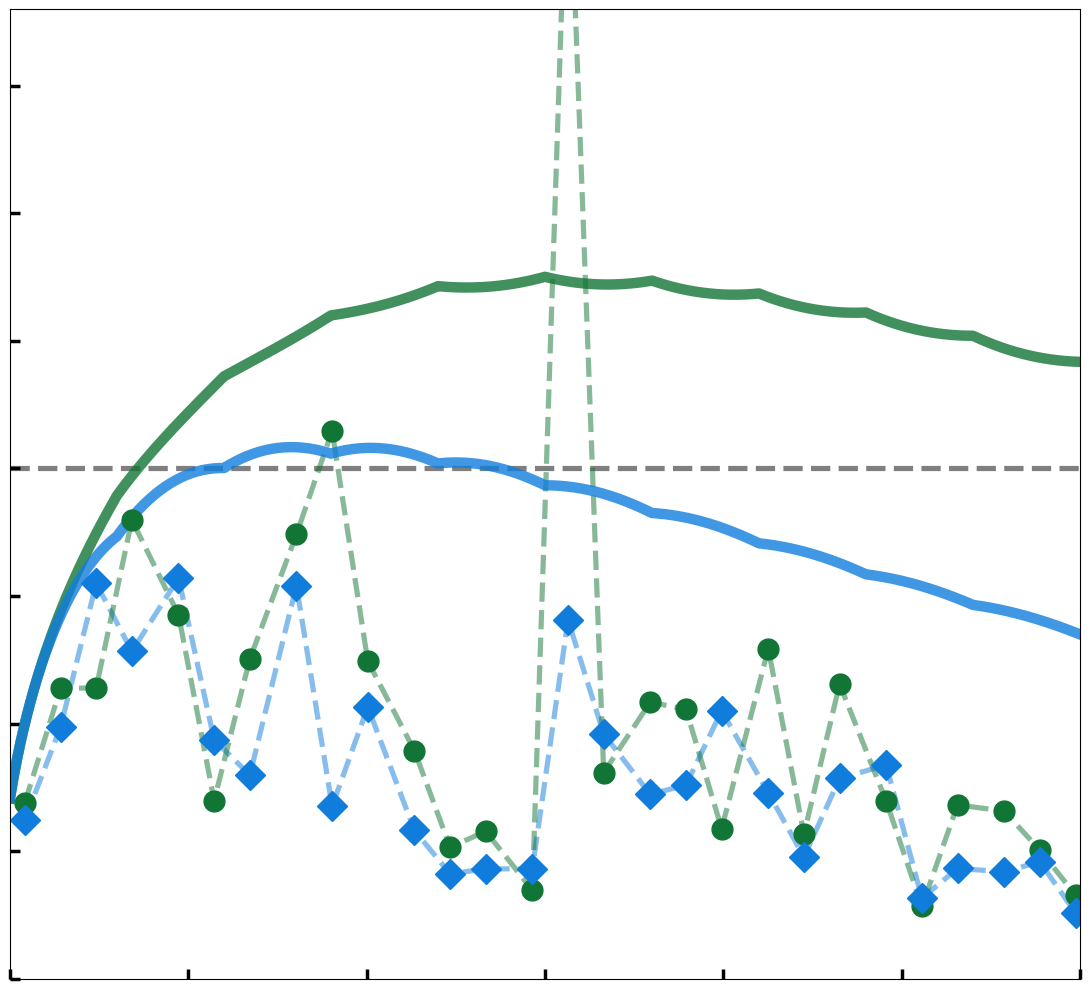

In [50]:
plt.figure(figsize=(11, 10))
plt.axhline(y = 1.0, color = 'k', ls = '--', lw = linewidth/2, alpha = 0.5)
plt.errorbar(delays_multi, snr_set_1_ket0/bare_snr_set_1, yerr = None, fmt='o', color = '#117535', ecolor = '#117535', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|0\rangle$ EXP', ls = None)
plt.errorbar(delays_multi, snr_set_1_ket1/bare_snr_set_1, yerr = None, fmt='D', color = '#107DDD', ecolor = '#107DDD', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|1\rangle$ EXP', ls = None)
plt.plot(delays_multi, snr_set_1_ket1/bare_snr_set_1, color = '#107DDD', ls='--', alpha = 0.5, lw=linewidth/2)
plt.plot(delays_multi, snr_set_1_ket0/bare_snr_set_1, color = '#117535', ls='--', alpha = 0.5, lw=linewidth/2)
plt.plot(times, snr_set_1_ket0_th/bare_snr_set_1_th, label = r'$|0\rangle$ Theoretical', ls='-', color = '#117535', linewidth = linewidth, alpha = 0.8)
plt.plot(times, snr_set_1_ket1_th/bare_snr_set_1_th, label = r'$|1\rangle$ Theoretical', ls='-', color= '#107DDD', linewidth = linewidth, alpha = 0.8)
plt.xlim(0, 300)
plt.ylim(0, 1.9)
# plt.legend(fontsize = 20)
# plt.tick_params(axis='both', direction='in', labelsize = 20, width = 2.5, size = 7.5)
plt.tick_params(axis='both', direction='in', labelsize = 0, width = 2.5, size = 7.5, labelleft = False, labelbottom = False)
# plt.xlabel('Delay [μs]', fontsize = 24)
# plt.ylabel(r'Gain', fontsize = 24)
plt.tight_layout()
# plt.savefig('fig7_Set_1_empty.pdf', bbox_inches='tight', pad_inches=0, dpi = 300)

# Set 2

In [27]:
set2_T1 = 240
set2_T2 = 70
qubit_set2 = obj.storage['multi_qec_30_1']['qubit_pos'][5]
bare_f_measure_2 = [obj.storage['bare_qubit']['fids'][f'{qubit}'][0] for qubit in qubit_set2]

In [33]:
data_set2 = get_th_approx_data(set2_T1, set2_T2, times, relaxation_time)
bare_snr_set_2_th = snr_th(f=data_set2['bare_qubit']['fids'], p=1.0, f_measure=bare_f_measure_2[1], n_measure=1)
snr_set_2_ket0_th = snr_th(f=data_set2['multi_qec_0_approx']['fids'], p=data_set2['multi_qec_0_approx']['probs'], f_measure=np.mean(bare_f_measure_2), n_measure=4)
snr_set_2_ket1_th = snr_th(f=data_set2['multi_qec_1_approx']['fids'], p=data_set2['multi_qec_1_approx']['probs'], f_measure=np.mean(bare_f_measure_2), n_measure=4)
# snr_set_2_ket0_th = snr_th(f=data_set2['multi_qec_0_approx']['fids'], p=np.array(obj.storage[f'multi_qec_30_0']['success_rates']['5']), f_measure=np.mean(bare_f_measure_2), n_measure=4)
# snr_set_2_ket1_th = snr_th(f=data_set2['multi_qec_1_approx']['fids'], p=np.array(obj.storage[f'multi_qec_30_1']['success_rates']['5']), f_measure=np.mean(bare_f_measure_2), n_measure=4)

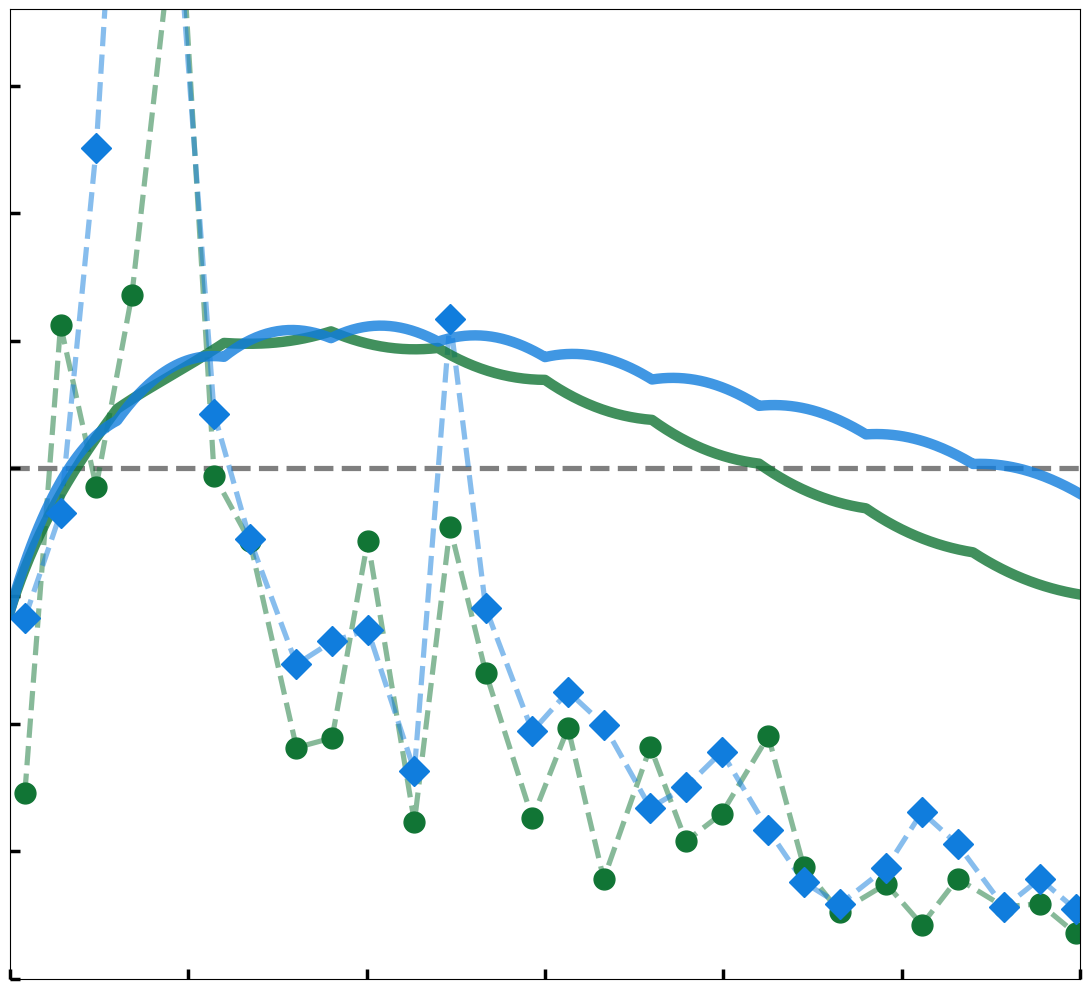

In [34]:
plt.figure(figsize=(11, 10))
plt.axhline(y = 1.0, color = 'k', ls = '--', lw = linewidth/2, alpha = 0.5)
plt.errorbar(delays_multi, snr_set_2_ket0/bare_snr_set_2, yerr = None, fmt='o', color = '#117535', ecolor = '#117535', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|0\rangle$ EXP', ls = None)
plt.errorbar(delays_multi, snr_set_2_ket1/bare_snr_set_2, yerr = None, fmt='D', color = '#107DDD', ecolor = '#107DDD', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|1\rangle$ EXP', ls = None)
plt.plot(delays_multi, snr_set_2_ket0/bare_snr_set_2, color = '#117535', ls='--', alpha = 0.5, lw=linewidth/2)
plt.plot(delays_multi, snr_set_2_ket1/bare_snr_set_2, color = '#107DDD', ls='--', alpha = 0.5, lw=linewidth/2)
plt.plot(times, snr_set_2_ket0_th/bare_snr_set_2_th, label = r'$|0\rangle$ Theoretical', ls='-', color = '#117535', linewidth = linewidth, alpha = 0.8)
plt.plot(times, snr_set_2_ket1_th/bare_snr_set_2_th, label = r'$|1\rangle$ Theoretical', ls='-', color= '#107DDD', linewidth = linewidth, alpha = 0.8)
plt.xlim(0, 300)
plt.ylim(0, 1.9)
plt.tick_params(axis='both', direction='in', labelsize = 0, width = 2.5, size = 7.5, labelleft = False, labelbottom = False)
# plt.legend(fontsize = 20)
# plt.tick_params(axis='both', direction='in', labelsize = 20, width = 2.5, size = 7.5)
# plt.xlabel('Delay [μs]', fontsize = 24)
# plt.ylabel(r'Gain', fontsize = 24)
plt.tight_layout()
# plt.savefig('fig7_Set_2_empty.pdf', bbox_inches='tight', pad_inches=0, dpi = 300)